<!-- # Dataset Loading -->

# EEG CONFORMER

Hybrid approach with convolutional and transformer modules.
Convolutional module learns low-level features, transformer module learns long-term dependencies.   
Source:
https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9991178



#                               

## 1. Loading the dataset

In [25]:
# imports 
import h5py
import os
import numpy as np
from scipy.signal import decimate
import matplotlib.pyplot as plt
import torch.nn as nn

In [26]:
# function to extract dataset name from file name
def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

# testing the function
filename_path= "../Final Project data/Intra/train/rest_105923_1.h5"
with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    print(dataset_name)
    matrix = f.get(dataset_name)[()]
    print(type(matrix))
    print(matrix.shape)

rest_105923
<class 'numpy.ndarray'>
(248, 35624)


<!-- # Visualize the data -->

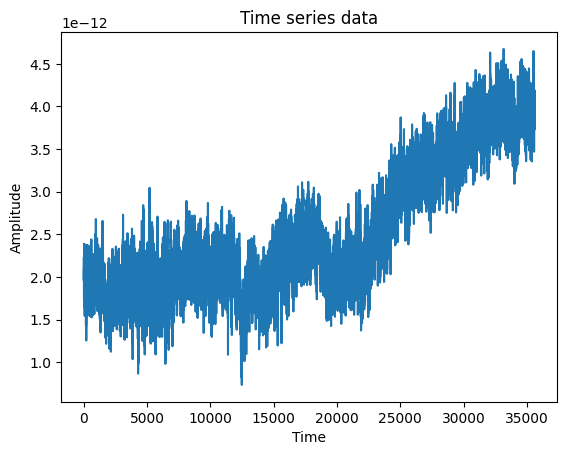

In [27]:
# visualise the data into 2D plot
import matplotlib.pyplot as plt
plt.plot(matrix[0])
plt.title('Time series data')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

<!-- # Preprocessing -->

## 2. Preprocessing the data
steps taken: 
- Z-score normalization

In [28]:
def prepare_data(file_path):
    with h5py.File(file_path, 'r') as f:
        name = "_".join(os.path.basename(file_path).split('_')[:-1])
        matrix = f.get(name)[()]
    # normalize per-channel (each sensor gets its own mean/std over time)
    mean = matrix.mean(axis=1, keepdims=True)
    std  = matrix.std(axis=1, keepdims=True)
    return ((matrix - mean) / (std + 1e-8)).astype(np.float32)

# # testing the function
# data_norm = prepare_data(filename_path)
# data_downsampled = decimate(data_norm, q=8, axis=1).astype(np.float32)
# print("Normalized shape:", data_norm.shape)
# print("Downsampled shape:", data_downsampled.shape)

<!-- # Creating train and test sets -->

## 3. Creating train and test sets
- 80% for training, 20% for validation
- Stratified sampling to maintain class distribution
- DataLoader for batching and shuffling


In [29]:
from sklearn.model_selection import train_test_split

LABEL_MAP = {
    'rest': 0,
    'task_story_math': 1,
    'task_working_memory': 2,
    'task_motor': 3,
}

def get_label(filename):
    base = os.path.basename(filename)
    for task, idx in LABEL_MAP.items():
        if base.startswith(task):
            return idx
    raise ValueError(f"Unknown task: {filename}")

def load_all_data(data_dir, downsample_factor=4):
    data_list, label_list = [], []
    for fname in sorted(os.listdir(data_dir)):
        if not fname.endswith('.h5'):
            continue
        path = os.path.join(data_dir, fname)
        data = prepare_data(path)
        data = decimate(data, q=downsample_factor, axis=1).astype(np.float32)
        data_list.append(data)
        label_list.append(get_label(fname))
    return data_list, label_list

# load raw files
train_data, train_labels = load_all_data("../Final Project data/Intra/train/")
test_data,  test_labels  = load_all_data("../Final Project data/Intra/test/")

# split training files into train / val (file-level split to avoid leakage)
train_files, val_files, train_lbls, val_lbls = train_test_split(
    train_data, train_labels,
    test_size=0.2,
    stratify=train_labels,
    random_state=42,
)

print(f"Train files: {len(train_files)} | Val files: {len(val_files)} | Test files: {len(test_data)}")
print(f"Train labels: {sorted(set(train_lbls))} | Val labels: {sorted(set(val_lbls))}")

Train files: 25 | Val files: 7 | Test files: 8
Train labels: [0, 1, 2, 3] | Val labels: [0, 1, 2, 3]


<!-- # Building the Vision Transformer -->

## PyTorch Dataset (Sliding Windows)
- Custom Dataset class to load and preprocess data on-the-fly
- Sliding window approach to create multiple samples from each recording


In [30]:
import torch
from torch.utils.data import Dataset, DataLoader

class MEGDataset(Dataset):
    def __init__(self, data_list, label_list, window=500, stride=125):
        self.samples, self.labels = [], []
        for data, label in zip(data_list, label_list):
            T = data.shape[1]
            for start in range(0, T - window + 1, stride):
                self.samples.append(data[:, start:start + window])
                self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.samples[idx]).unsqueeze(0)  # (1, 248, window)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

WINDOW = 500
STRIDE = 62

train_ds = MEGDataset(train_files, train_lbls,  window=WINDOW, stride=STRIDE)
val_ds   = MEGDataset(val_files,   val_lbls,    window=WINDOW, stride=STRIDE)
test_ds  = MEGDataset(test_data,   test_labels, window=WINDOW, stride=STRIDE)

print(f"Train windows: {len(train_ds)}")
print(f"Val windows:   {len(val_ds)}")
print(f"Test windows:  {len(test_ds)}  ← only touched at the very end")

Train windows: 3400
Val windows:   952
Test windows:  1088  ← only touched at the very end


## EEG Conformer Model

In [31]:
import torch.nn as nn

class ConvModule(nn.Module):
    def __init__(self, n_channels=248, n_filters=40, kernel_temp=25,
                 pool_size=75, pool_stride=15, dropout=0.5):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv2d(1, n_filters, kernel_size=(1, kernel_temp), bias=False),
            nn.BatchNorm2d(n_filters),
        )
        self.spatial = nn.Sequential(
            nn.Conv2d(n_filters, n_filters, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(n_filters),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, pool_size), stride=(1, pool_stride)),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (B, 1, C, T)
        x = self.temporal(x)       # (B, 40, C, T-24)
        x = self.spatial(x)        # (B, 40, 1, T')
        x = x.squeeze(2)           # (B, 40, T')
        return x.permute(0, 2, 1)  # (B, T', 40)


class EEGConformer(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, window=500,
                 n_filters=40, kernel_temp=25, pool_size=75, pool_stride=15,
                 num_heads=8, num_layers=6, ff_dim=80, dropout=0.5):
        super().__init__()
        self.conv = ConvModule(n_channels, n_filters, kernel_temp,
                               pool_size, pool_stride, dropout)

        T_after_temp = window - kernel_temp + 1
        T_seq = (T_after_temp - pool_size) // pool_stride + 1

        # learnable positional embedding — gives the transformer token-order information
        self.pos_embedding = nn.Parameter(torch.randn(1, T_seq, n_filters) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=n_filters, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            activation='gelu', batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(n_filters)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(T_seq * n_filters, 256),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 32),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        # x: (B, 1, C, T)
        x = self.conv(x)            # (B, T', 40)
        x = x + self.pos_embedding  # inject positional information
        x = self.transformer(x)     # (B, T', 40)
        x = self.norm(x)
        return self.classifier(x)   # (B, n_classes)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EEGConformer(n_channels=248, n_classes=4, window=WINDOW).to(device)
print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

dummy = torch.zeros(2, 1, 248, WINDOW).to(device)
print(f"Output shape: {model(dummy).shape}")  # expected: (2, 4)

Device: cpu
Parameters: 763,652
Output shape: torch.Size([2, 4])


## Training

In [32]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

def run_epoch(loader, model, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct = 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct += (out.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

## Hyperparameter Grid Search

In [33]:
# import itertools

# def train_model(num_layers, dropout, lr, n_epochs=30, patience=5):
#     """Train a fresh EEGConformer with given hyperparams, return best val acc + state dict."""
#     m = EEGConformer(
#         n_channels=248, n_classes=4, window=WINDOW,
#         num_layers=num_layers, dropout=dropout,
#     ).to(device)
#     opt  = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
#     crit = nn.CrossEntropyLoss()

#     def epoch_pass(loader, train):
#         m.train() if train else m.eval()
#         total_loss, correct = 0, 0
#         ctx = torch.enable_grad() if train else torch.no_grad()
#         with ctx:
#             for x, y in loader:
#                 x, y = x.to(device), y.to(device)
#                 out  = m(x)
#                 loss = crit(out, y)
#                 if train:
#                     opt.zero_grad()
#                     loss.backward()
#                     opt.step()
#                 total_loss += loss.item() * len(y)
#                 correct    += (out.argmax(1) == y).sum().item()
#         return total_loss / len(loader.dataset), correct / len(loader.dataset)

#     best_val, counter, best_state = 0, 0, None
#     for _ in range(n_epochs):
#         epoch_pass(train_loader, train=True)
#         _, vl_acc = epoch_pass(val_loader, train=False)
#         if vl_acc > best_val:
#             best_val   = vl_acc
#             best_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}
#             counter    = 0
#         else:
#             counter += 1
#             if counter >= patience:
#                 break

#     return best_val, best_state


# param_grid = {
#     'num_layers': [2, 4, 6],
#     'dropout':    [0.3, 0.5],
#     'lr':         [1e-3, 5e-4],
# }

# keys         = list(param_grid.keys())
# combinations = list(itertools.product(*param_grid.values()))
# print(f"Total combinations: {len(combinations)}\n")

# gs_results = []
# for combo in combinations:
#     params = dict(zip(keys, combo))
#     print(f"Testing {params} ...", end=' ', flush=True)
#     val_acc, state = train_model(**params)
#     gs_results.append({**params, 'val_acc': val_acc, 'state': state})
#     print(f"val acc: {val_acc:.3f}")

# gs_results.sort(key=lambda x: x['val_acc'], reverse=True)

# print("\n" + "=" * 52)
# print(f"{'layers':>8} {'dropout':>9} {'lr':>8} {'val_acc':>10}")
# print("=" * 52)
# for r in gs_results:
#     print(f"{r['num_layers']:>8} {r['dropout']:>9} {r['lr']:>8.0e} {r['val_acc']:>10.3f}")

# best_params = {k: gs_results[0][k] for k in keys}
# print(f"\nBest: {best_params}  (val acc: {gs_results[0]['val_acc']:.3f})")

In [34]:
# import json

# # run this cell after the grid search to persist results to disk
# gs_summary = [{k: v for k, v in r.items() if k != 'state'} for r in gs_results]
# with open('gs_best_params.json', 'w') as f:
#     json.dump(best_params, f, indent=2)
# with open('gs_summary.json', 'w') as f:
#     json.dump(gs_summary, f, indent=2)
# torch.save(gs_results[0]['state'], 'best_gs_model.pt')

# print(f"Saved: gs_best_params.json, gs_summary.json, best_gs_model.pt")
# print(f"Best params: {best_params}")

In [35]:
# add num_layers=2, dropout=0.3, lr=5e-3 to best_params  -> fallback params IGNORE
best_params = {
    'num_layers': 2,
    'dropout': 0.3,
    'lr': 5e-3,
}

In [36]:
# import matplotlib.pyplot as plt
# # load the best model found during grid search and evaluate on test — done exactly once
# criterion    = nn.CrossEntropyLoss()
# model_params = {k: v for k, v in best_params.items() if k != 'lr'}
# model = EEGConformer(n_channels=248, n_classes=4, window=WINDOW, **model_params).to(device)
# model.load_state_dict({k: v.to(device) for k, v in gs_results[0]['state'].items()})

# _, te_acc = run_epoch(test_loader, model, criterion, train=False)
# print(f"Best grid-search params: {best_params}")
# print(f"Final test accuracy:     {te_acc:.3f}")

# # bar chart of all combinations
# labels   = [f"L{r['num_layers']} D{r['dropout']} lr{r['lr']:.0e}" for r in gs_results]
# val_accs = [r['val_acc'] for r in gs_results]
# colors   = ['darkorange' if r == gs_results[0] else 'steelblue' for r in gs_results]

# plt.figure(figsize=(12, 4))
# plt.bar(labels, val_accs, color=colors)
# plt.axhline(0.25, color='grey', linestyle='--', linewidth=0.8, label='Random (25%)')
# plt.xticks(rotation=45, ha='right', fontsize=8)
# plt.ylabel('Val Accuracy')
# plt.title('Grid Search Results  (orange = best)')
# plt.ylim(0, 1)
# plt.tight_layout()
# plt.show()

## Final Model: Train on Full Data (Train + Val)

In [37]:
# # merge train and val — no val set needed once hyperparams are fixed
# all_train_data   = train_files + val_files
# all_train_labels = train_lbls  + val_lbls

# full_train_ds = MEGDataset(all_train_data, all_train_labels, window=WINDOW, stride=STRIDE)
# full_loader   = DataLoader(full_train_ds, batch_size=32, shuffle=True, num_workers=0)
# print(f"Full training windows: {len(full_train_ds)}")

# BEST_N_EPOCHS = 15  # adjust based on when grid search best combo converged

# criterion    = nn.CrossEntropyLoss()
# model_params = {k: v for k, v in best_params.items() if k != 'lr'}
# model        = EEGConformer(n_channels=248, n_classes=4, window=WINDOW, **model_params).to(device)
# optimizer    = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=1e-4)

# history_full = {'train_loss': [], 'train_acc': []}
# for epoch in range(BEST_N_EPOCHS):
#     tr_loss, tr_acc = run_epoch(full_loader, model, criterion, optimizer, train=True)
#     history_full['train_loss'].append(tr_loss)
#     history_full['train_acc'].append(tr_acc)
#     print(f"Epoch {epoch+1:02d}/{BEST_N_EPOCHS} | loss {tr_loss:.4f} | acc {tr_acc:.3f}")

# _, te_acc = run_epoch(test_loader, model, criterion, train=False)
# print(f"\nFinal test accuracy (full train+val): {te_acc:.3f}")

In [38]:
# epochs_range = range(1, len(history_full['train_acc']) + 1)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ax1.plot(epochs_range, history_full['train_acc'], label='Train', color='steelblue')
# ax1.axhline(te_acc, color='red',  linestyle='--', linewidth=1.5, label=f'Test ({te_acc:.3f})')
# ax1.axhline(0.25,   color='grey', linestyle=':',  linewidth=0.8, label='Random (25%)')
# ax1.set_title('Accuracy — Final Model (train+val)')
# ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
# ax1.legend(); ax1.set_ylim(0, 1)

# ax2.plot(epochs_range, history_full['train_loss'], label='Train', color='steelblue')
# ax2.set_title('Loss — Final Model (train+val)')
# ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
# ax2.legend()

# plt.tight_layout()
# plt.show()

## Comparison: Global Average Pooling Classifier

In [39]:
class EEGConformerGAP(nn.Module):
    """EEG Conformer with global average pooling instead of flatten+linear classifier."""
    def __init__(self, n_channels=248, n_classes=4, window=500,
                 n_filters=40, kernel_temp=25, pool_size=75, pool_stride=15,
                 num_heads=8, num_layers=2, ff_dim=80, dropout=0.3):
        super().__init__()
        self.conv = ConvModule(n_channels, n_filters, kernel_temp,
                               pool_size, pool_stride, dropout)

        T_after_temp = window - kernel_temp + 1
        T_seq = (T_after_temp - pool_size) // pool_stride + 1

        self.pos_embedding = nn.Parameter(torch.randn(1, T_seq, n_filters) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=n_filters, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            activation='gelu', batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(n_filters)

        # GAP: average over time tokens → (B, 40) → classify
        self.classifier = nn.Linear(n_filters, n_classes)

    def forward(self, x):
        x = self.conv(x)
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = self.norm(x)
        x = x.mean(dim=1)          # global average over T' tokens → (B, 40)
        return self.classifier(x)


# # train on full data (train+val) with same setup as final model
# gap_model = EEGConformerGAP(n_channels=248, n_classes=4, window=WINDOW).to(device)
# gap_optimizer = torch.optim.Adam(gap_model.parameters(), lr=5e-4, weight_decay=1e-4)
# gap_criterion = nn.CrossEntropyLoss()

# print(f"GAP model parameters: {sum(p.numel() for p in gap_model.parameters()):,}")
# print(f"Original model parameters: {sum(p.numel() for p in model.parameters()):,}")

# gap_history = {'train_loss': [], 'train_acc': []}
# for epoch in range(BEST_N_EPOCHS):
#     tr_loss, tr_acc = run_epoch(full_loader, gap_model, gap_criterion, gap_optimizer, train=True)
#     gap_history['train_loss'].append(tr_loss)
#     gap_history['train_acc'].append(tr_acc)
#     print(f"Epoch {epoch+1:02d}/{BEST_N_EPOCHS} | loss {tr_loss:.4f} | acc {tr_acc:.3f}")

# _, gap_te_acc = run_epoch(test_loader, gap_model, gap_criterion, train=False)
# print(f"\nGAP test accuracy:      {gap_te_acc:.3f}")
# print(f"Original test accuracy: {te_acc:.3f}")

# # comparison plot
# epochs_range = range(1, BEST_N_EPOCHS + 1)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ax1.plot(epochs_range, history_full['train_acc'], label='Original (flatten)', color='steelblue')
# ax1.plot(epochs_range, gap_history['train_acc'],  label='GAP',               color='darkorange')
# ax1.axhline(te_acc,     color='steelblue', linestyle='--', linewidth=1.2, label=f'Original test ({te_acc:.3f})')
# ax1.axhline(gap_te_acc, color='darkorange', linestyle='--', linewidth=1.2, label=f'GAP test ({gap_te_acc:.3f})')
# ax1.axhline(0.25, color='grey', linestyle=':', linewidth=0.8, label='Random (25%)')
# ax1.set_title('Accuracy Comparison'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
# ax1.legend(); ax1.set_ylim(0, 1)

# ax2.plot(epochs_range, history_full['train_loss'], label='Original (flatten)', color='steelblue')
# ax2.plot(epochs_range, gap_history['train_loss'],  label='GAP',               color='darkorange')
# ax2.set_title('Loss Comparison'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
# ax2.legend()

# plt.tight_layout()
# plt.show()

In [40]:
# # save best model

# torch.save(gap_model.state_dict(), 'final_best_gap_model.pt')
# print("Saved final_best_model.pt")

In [41]:
# # define model from saved final_best_gap_model.pt
# final_model = EEGConformerGAP(n_channels=248, n_classes=4, window=WINDOW).to(device)
# final_model.load_state_dict(torch.load('final_best_gap_model.pt', map_location=device))

## Cross-Subject Classification

In [42]:
import itertools
# ── load cross-subject data ──────────────────────────────────────────────────
cross_train_data,  cross_train_labels  = load_all_data("../Final Project data/Cross/train/")
cross_test1_data,  cross_test1_labels  = load_all_data("../Final Project data/Cross/test1/")
cross_test2_data,  cross_test2_labels  = load_all_data("../Final Project data/Cross/test2/")
cross_test3_data,  cross_test3_labels  = load_all_data("../Final Project data/Cross/test3/")

# file-level train/val split (same strategy as intra-subject)
cross_train_files, cross_val_files, cross_train_lbls, cross_val_lbls = train_test_split(
    cross_train_data, cross_train_labels,
    test_size=0.2, stratify=cross_train_labels, random_state=42,
)

print(f"Cross train files: {len(cross_train_files)} | val: {len(cross_val_files)}")
print(f"Test subjects — test1: {len(cross_test1_data)} | test2: {len(cross_test2_data)} | test3: {len(cross_test3_data)}")

# ── datasets & loaders ────────────────────────────────────────────────────────
cross_train_ds = MEGDataset(cross_train_files, cross_train_lbls, window=WINDOW, stride=STRIDE)
cross_val_ds   = MEGDataset(cross_val_files,   cross_val_lbls,   window=WINDOW, stride=STRIDE)
cross_test1_ds = MEGDataset(cross_test1_data,  cross_test1_labels, window=WINDOW, stride=STRIDE)
cross_test2_ds = MEGDataset(cross_test2_data,  cross_test2_labels, window=WINDOW, stride=STRIDE)
cross_test3_ds = MEGDataset(cross_test3_data,  cross_test3_labels, window=WINDOW, stride=STRIDE)

cross_train_loader = DataLoader(cross_train_ds, batch_size=32, shuffle=True,  num_workers=0)
cross_val_loader   = DataLoader(cross_val_ds,   batch_size=32, shuffle=False, num_workers=0)
cross_test1_loader = DataLoader(cross_test1_ds, batch_size=32, shuffle=False, num_workers=0)
cross_test2_loader = DataLoader(cross_test2_ds, batch_size=32, shuffle=False, num_workers=0)
cross_test3_loader = DataLoader(cross_test3_ds, batch_size=32, shuffle=False, num_workers=0)

print(f"\nTrain windows: {len(cross_train_ds)} | Val windows: {len(cross_val_ds)}")
print(f"Test windows  — test1: {len(cross_test1_ds)} | test2: {len(cross_test2_ds)} | test3: {len(cross_test3_ds)}")

# # ── grid search ───────────────────────────────────────────────────────────────
# def train_model_gap(num_layers, dropout, lr, n_epochs=30, patience=5):
#     m    = EEGConformerGAP(n_channels=248, n_classes=4, window=WINDOW,
#                            num_layers=num_layers, dropout=dropout).to(device)
#     opt  = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
#     crit = nn.CrossEntropyLoss()

#     def epoch_pass(loader, train):
#         m.train() if train else m.eval()
#         total_loss, correct = 0, 0
#         ctx = torch.enable_grad() if train else torch.no_grad()
#         with ctx:
#             for x, y in loader:
#                 x, y = x.to(device), y.to(device)
#                 out  = m(x)
#                 loss = crit(out, y)
#                 if train:
#                     opt.zero_grad(); loss.backward(); opt.step()
#                 total_loss += loss.item() * len(y)
#                 correct    += (out.argmax(1) == y).sum().item()
#         return total_loss / len(loader.dataset), correct / len(loader.dataset)

#     best_val, counter, best_state = 0, 0, None
#     for _ in range(n_epochs):
#         epoch_pass(cross_train_loader, train=True)
#         _, vl_acc = epoch_pass(cross_val_loader, train=False)
#         if vl_acc > best_val:
#             best_val   = vl_acc
#             best_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}
#             counter    = 0
#         else:
#             counter += 1
#             if counter >= patience:
#                 break
#     return best_val, best_state

# param_grid = {
#     'num_layers': [2, 4, 6],
#     'dropout':    [0.3, 0.5],
#     'lr':         [1e-3, 5e-4],
# }
# keys         = list(param_grid.keys())
# combinations = list(itertools.product(*param_grid.values()))
# print(f"\nTotal combinations: {len(combinations)}\n")

# cross_gs_results = []
# for combo in combinations:
#     params = dict(zip(keys, combo))
#     print(f"Testing {params} ...", end=' ', flush=True)
#     val_acc, state = train_model_gap(**params)
#     cross_gs_results.append({**params, 'val_acc': val_acc, 'state': state})
#     print(f"val acc: {val_acc:.3f}")

# cross_gs_results.sort(key=lambda x: x['val_acc'], reverse=True)

# print("\n" + "=" * 52)
# print(f"{'layers':>8} {'dropout':>9} {'lr':>8} {'val_acc':>10}")
# print("=" * 52)
# for r in cross_gs_results:
#     print(f"{r['num_layers']:>8} {r['dropout']:>9} {r['lr']:>8.0e} {r['val_acc']:>10.3f}")

# cross_best_params = {k: cross_gs_results[0][k] for k in keys}
# print(f"\nBest: {cross_best_params}  (val acc: {cross_gs_results[0]['val_acc']:.3f})")

Cross train files: 51 | val: 13
Test subjects — test1: 16 | test2: 16 | test3: 16

Train windows: 6936 | Val windows: 1768
Test windows  — test1: 2176 | test2: 2176 | test3: 2176


In [43]:
cross_best_params = {
    'num_layers': 2,
    'dropout': 0.3,
    'lr': 5e-4,
}

In [44]:
# import json

# # save cross-subject grid search results to disk
# cross_gs_summary = [{k: v for k, v in r.items() if k != 'state'} for r in cross_gs_results]
# with open('cross_gs_best_params.json', 'w') as f:
#     json.dump(cross_best_params, f, indent=2)
# with open('cross_gs_summary.json', 'w') as f:
#     json.dump(cross_gs_summary, f, indent=2)
# torch.save(cross_gs_results[0]['state'], 'cross_best_gs_model.pt')

# print(f"Saved cross-subject results.")
# print(f"Best params: {cross_best_params}")

In [45]:
# # evaluate best cross-subject model on all three test subjects
# cross_criterion  = nn.CrossEntropyLoss()
# cross_model_params = {k: v for k, v in best_params.items() if k != 'lr'}
# cross_model = EEGConformerGAP(n_channels=248, n_classes=4, window=WINDOW,
#                                **cross_model_params).to(device)
# cross_model.load_state_dict(torch.load('cross_best_gs_model.pt', map_location=device))

# _, acc1 = run_epoch(cross_test1_loader, cross_model, cross_criterion, train=False)
# _, acc2 = run_epoch(cross_test2_loader, cross_model, cross_criterion, train=False)
# _, acc3 = run_epoch(cross_test3_loader, cross_model, cross_criterion, train=False)
# mean_acc = (acc1 + acc2 + acc3) / 3

# print(f"Best params: {best_params}")
# print(f"Test subject 1 acc: {acc1:.3f}")
# print(f"Test subject 2 acc: {acc2:.3f}")
# print(f"Test subject 3 acc: {acc3:.3f}")
# print(f"Mean test acc:      {mean_acc:.3f}")

# # bar chart per subject
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# # per-subject accuracy
# subjects = ['Subject 1', 'Subject 2', 'Subject 3']
# accs = [acc1, acc2, acc3]
# colors = ['steelblue' if a < mean_acc else 'darkorange' for a in accs]
# ax1.bar(subjects, accs, color=colors)
# ax1.axhline(mean_acc, color='red',  linestyle='--', linewidth=1.2, label=f'Mean ({mean_acc:.3f})')
# ax1.axhline(0.25,     color='grey', linestyle=':',  linewidth=0.8, label='Random (25%)')
# ax1.set_title('Cross-Subject Test Accuracy per Subject')
# ax1.set_ylabel('Accuracy'); ax1.set_ylim(0, 1); ax1.legend()

# # # grid search bar chart
# # labels   = [f"L{r['num_layers']} D{r['dropout']} lr{r['lr']:.0e}" for r in cross_gs_results]
# # val_accs = [r['val_acc'] for r in cross_gs_results]
# # bar_colors = ['darkorange' if i == 0 else 'steelblue' for i in range(len(cross_gs_results))]
# # ax2.bar(labels, val_accs, color=bar_colors)
# # ax2.axhline(0.25, color='grey', linestyle='--', linewidth=0.8, label='Random (25%)')
# # ax2.set_title('Cross-Subject Grid Search (orange = best)')
# # ax2.set_ylabel('Val Accuracy'); ax2.set_ylim(0, 1)
# # ax2.tick_params(axis='x', rotation=45); ax2.legend()

# plt.tight_layout()
# plt.show()

In [46]:
# import matplotlib.pyplot as plt
# # reuse best hyperparams from intra-subject (layers=2, dropout=0.3, lr=5e-4)
# cross_best_params = {'num_layers': 2, 'dropout': 0.3, 'lr': 5e-4}

# # train on all cross-subject train data (no val split needed)
# cross_all_data   = cross_train_data
# cross_all_labels = cross_train_labels

# cross_full_ds     = MEGDataset(cross_all_data, cross_all_labels, window=WINDOW, stride=STRIDE)
# cross_full_loader = DataLoader(cross_full_ds, batch_size=32, shuffle=True, num_workers=0)
# print(f"Cross full train windows: {len(cross_full_ds)}")

# CROSS_N_EPOCHS = 15

# cross_criterion  = nn.CrossEntropyLoss()
# cross_model      = EEGConformerGAP(n_channels=248, n_classes=4, window=WINDOW,
#                                    num_layers=cross_best_params['num_layers'],
#                                    dropout=cross_best_params['dropout']).to(device)
# cross_optimizer  = torch.optim.Adam(cross_model.parameters(),
#                                     lr=cross_best_params['lr'], weight_decay=1e-4)

# cross_history = {'train_loss': [], 'train_acc': []}
# for epoch in range(CROSS_N_EPOCHS):
#     tr_loss, tr_acc = run_epoch(cross_full_loader, cross_model, cross_criterion,
#                                 cross_optimizer, train=True)
#     cross_history['train_loss'].append(tr_loss)
#     cross_history['train_acc'].append(tr_acc)
#     print(f"Epoch {epoch+1:02d}/{CROSS_N_EPOCHS} | loss {tr_loss:.4f} | acc {tr_acc:.3f}")

# # evaluate on all three test subjects
# _, acc1 = run_epoch(cross_test1_loader, cross_model, cross_criterion, train=False)
# _, acc2 = run_epoch(cross_test2_loader, cross_model, cross_criterion, train=False)
# _, acc3 = run_epoch(cross_test3_loader, cross_model, cross_criterion, train=False)
# mean_acc = (acc1 + acc2 + acc3) / 3

# print(f"\nTest subject 1 acc: {acc1:.3f}")
# print(f"Test subject 2 acc: {acc2:.3f}")
# print(f"Test subject 3 acc: {acc3:.3f}")
# print(f"Mean test acc:      {mean_acc:.3f}")

# # plots
# epochs_range = range(1, CROSS_N_EPOCHS + 1)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ax1.plot(epochs_range, cross_history['train_acc'], color='steelblue', label='Train')
# ax1.axhline(mean_acc, color='red',  linestyle='--', linewidth=1.5, label=f'Mean test ({mean_acc:.3f})')
# ax1.axhline(0.25,     color='grey', linestyle=':',  linewidth=0.8, label='Random (25%)')
# ax1.set_title('Cross-Subject Training Accuracy')
# ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
# ax1.legend(); ax1.set_ylim(0, 1)

# subjects = ['Subject 1', 'Subject 2', 'Subject 3']
# accs     = [acc1, acc2, acc3]
# colors   = ['darkorange' if a >= mean_acc else 'steelblue' for a in accs]
# ax2.bar(subjects, accs, color=colors)
# ax2.axhline(mean_acc, color='red',  linestyle='--', linewidth=1.2, label=f'Mean ({mean_acc:.3f})')
# ax2.axhline(0.25,     color='grey', linestyle=':',  linewidth=0.8, label='Random (25%)')
# ax2.set_title('Cross-Subject Test Accuracy per Subject')
# ax2.set_ylabel('Accuracy'); ax2.set_ylim(0, 1); ax2.legend()

# plt.tight_layout()
# plt.show()

In [47]:
# # save final cross-subject model
# torch.save(cross_model.state_dict(), 'final_cross_subject_model.pt')
# print("Saved final_cross_subject_model.pt")

<!-- # Loading the model -->

In [48]:
# cross_model.load_state_dict(torch.load('final_cross_subject_model.pt', map_location=device))    

## Supervised Contrastive Learning (Cross-Subject)

In [49]:
import torch.nn.functional as F


class SupConLoss(nn.Module):
    """Supervised Contrastive Loss (Khosla et al., 2020)."""
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        # features: (B, D) L2-normalised; labels: (B,)
        B = features.shape[0]
        labels = labels.view(-1, 1)
        mask = (labels == labels.T).float().to(features.device)  # 1 where same class

        sim = torch.matmul(features, features.T) / self.temperature

        self_mask = torch.eye(B, device=features.device).bool()
        mask = mask.masked_fill(self_mask, 0)
        sim  = sim.masked_fill(self_mask, float('-inf'))

        log_prob = sim - torch.logsumexp(sim, dim=1, keepdim=True)
        n_pos = mask.sum(dim=1).clamp(min=1)
        return (-(mask * log_prob).sum(dim=1) / n_pos).mean()


class EEGConformerGAPSupCon(nn.Module):
    """EEGConformerGAP + projection head for supervised contrastive learning."""
    def __init__(self, n_channels=248, n_classes=4, window=500,
                 n_filters=40, kernel_temp=25, pool_size=75, pool_stride=15,
                 num_heads=8, num_layers=2, ff_dim=80, dropout=0.3, proj_dim=64):
        super().__init__()
        self.conv = ConvModule(n_channels, n_filters, kernel_temp,
                               pool_size, pool_stride, dropout)

        T_after_temp = window - kernel_temp + 1
        T_seq = (T_after_temp - pool_size) // pool_stride + 1

        self.pos_embedding = nn.Parameter(torch.randn(1, T_seq, n_filters) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=n_filters, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation='gelu', batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(n_filters)
        self.classifier = nn.Linear(n_filters, n_classes)
        self.proj_head = nn.Sequential(
            nn.Linear(n_filters, n_filters),
            nn.ReLU(),
            nn.Linear(n_filters, proj_dim),
        )

    def forward(self, x, return_embeds=False):
        x = self.conv(x)
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = self.norm(x)
        emb    = x.mean(dim=1)          # (B, n_filters)
        logits = self.classifier(emb)
        if return_embeds:
            proj = F.normalize(self.proj_head(emb), dim=1)
            return logits, proj
        return logits

In [50]:
# def run_epoch_supcon(loader, model, ce_crit, sc_crit, optimizer=None, train=True, alpha=0.5):
#     model.train() if train else model.eval()
#     total_loss, correct = 0, 0
#     ctx = torch.enable_grad() if train else torch.no_grad()
#     with ctx:
#         for x, y in loader:
#             x, y = x.to(device), y.to(device)
#             logits, proj = model(x, return_embeds=True)
#             loss = (1 - alpha) * ce_crit(logits, y) + alpha * sc_crit(proj, y)
#             if train:
#                 optimizer.zero_grad(); loss.backward(); optimizer.step()
#             total_loss += loss.item() * len(y)
#             correct    += (logits.argmax(1) == y).sum().item()
#     n = len(loader.dataset)
#     return total_loss / n, correct / n


# CROSS_SC_EPOCHS = 15
# SC_ALPHA        = 0.5   # weight of SupCon loss (1-alpha = CE weight)

# sc_ce_crit  = nn.CrossEntropyLoss()
# sc_con_crit = SupConLoss(temperature=0.07)

# sc_model = EEGConformerGAPSupCon(
#     n_channels=248, n_classes=4, window=WINDOW,
#     num_layers=cross_best_params['num_layers'],
#     dropout=cross_best_params['dropout'],
# ).to(device)
# sc_optimizer = torch.optim.Adam(sc_model.parameters(),
#                                 lr=cross_best_params['lr'], weight_decay=1e-4)

# # sc_history = {'train_loss': [], 'train_acc': []}

# # for epoch in range(CROSS_SC_EPOCHS):
# #     tr_loss, tr_acc = run_epoch_supcon(cross_full_loader, sc_model, sc_ce_crit, sc_con_crit,
# #                                        sc_optimizer, train=True, alpha=SC_ALPHA)
# #     sc_history['train_loss'].append(tr_loss)
# #     sc_history['train_acc'].append(tr_acc)
# #     print(f"Epoch {epoch+1:02d}/{CROSS_SC_EPOCHS} | loss {tr_loss:.4f} | acc {tr_acc:.3f}")

In [51]:
# def eval_acc(model, loader):
#     model.eval()
#     correct = 0
#     with torch.no_grad():
#         for x, y in loader:
#             x, y = x.to(device), y.to(device)
#             correct += (model(x).argmax(1) == y).sum().item()
#     return correct / len(loader.dataset)

# # load saved baseline model for comparison
# baseline_model = EEGConformerGAP(
#     n_channels=248, n_classes=4, window=WINDOW,
#     num_layers=cross_best_params['num_layers'],
#     dropout=cross_best_params['dropout'],
# ).to(device)
# baseline_model.load_state_dict(torch.load('final_cross_subject_model.pt', map_location=device))

# acc1     = eval_acc(baseline_model, cross_test1_loader)
# acc2     = eval_acc(baseline_model, cross_test2_loader)
# acc3     = eval_acc(baseline_model, cross_test3_loader)
# mean_acc = (acc1 + acc2 + acc3) / 3

# sc_acc1 = eval_acc(sc_model, cross_test1_loader)
# sc_acc2 = eval_acc(sc_model, cross_test2_loader)
# sc_acc3 = eval_acc(sc_model, cross_test3_loader)
# sc_mean  = (sc_acc1 + sc_acc2 + sc_acc3) / 3

# print(f"Baseline— S1: {acc1:.3f} | S2: {acc2:.3f} | S3: {acc3:.3f} | Mean: {mean_acc:.3f}")
# print(f"SupCon  — S1: {sc_acc1:.3f} | S2: {sc_acc2:.3f} | S3: {sc_acc3:.3f} | Mean: {sc_mean:.3f}")
# print(f"Delta: {sc_mean - mean_acc:+.3f}")

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# subjects = ['Subject 1', 'Subject 2', 'Subject 3']
# x = np.arange(len(subjects))
# w = 0.35
# axes[0].bar(x - w/2, [acc1,    acc2,    acc3],    w, label='Baseline (CE only)', color='steelblue')
# axes[0].bar(x + w/2, [sc_acc1, sc_acc2, sc_acc3], w, label='SupCon + CE',        color='darkorange')
# axes[0].axhline(0.25, color='grey', linestyle=':', linewidth=0.8, label='Random (25%)')
# axes[0].set_xticks(x); axes[0].set_xticklabels(subjects)
# axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1)
# axes[0].set_title('Baseline vs SupCon — Cross-Subject Test'); axes[0].legend()

# er = range(1, CROSS_SC_EPOCHS + 1)
# axes[1].plot(er, sc_history['train_acc'], color='darkorange', label='SupCon train')
# axes[1].axhline(0.25, color='grey', linestyle=':', linewidth=0.8, label='Random (25%)')
# axes[1].set_title('SupCon Training Curve')
# axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
# axes[1].legend(); axes[1].set_ylim(0, 1)

# plt.tight_layout(); plt.show()

# torch.save(sc_model.state_dict(), 'cross_supcon_model.pt')
# print("Saved cross_supcon_model.pt")

## CNN-Only Baseline (Ablation: no Transformer)

In [52]:
class CNNOnly(nn.Module):
    """ConvModule + GAP classifier — no transformer. Ablation to isolate CNN contribution."""
    def __init__(self, n_channels=248, n_classes=4, window=500,
                 n_filters=40, kernel_temp=25, pool_size=75, pool_stride=15,
                 dropout=0.3):
        super().__init__()
        self.conv = ConvModule(n_channels, n_filters, kernel_temp,
                               pool_size, pool_stride, dropout)
        self.classifier = nn.Linear(n_filters, n_classes)

    def forward(self, x):
        x = self.conv(x)        # (B, T', 40)
        x = x.mean(dim=1)       # GAP over T' → (B, 40)
        return self.classifier(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn_model = CNNOnly(n_channels=248, n_classes=4, window=WINDOW).to(device)
print(f"CNN-only parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")
dummy = torch.zeros(2, 1, 248, WINDOW).to(device)
print(f"Output shape: {cnn_model(dummy).shape}")

CNN-only parameters: 398,124
Output shape: torch.Size([2, 4])


### Intra-Subject: CNN-Only vs EEGConformerGAP

Epoch 01/30 | tr 1.2699/0.465 | val 1.3077/0.420
Epoch 02/30 | tr 1.1114/0.610 | val 1.1910/0.441
Epoch 03/30 | tr 1.0098/0.681 | val 1.1299/0.425
Epoch 04/30 | tr 0.9228/0.731 | val 1.1402/0.432
Epoch 05/30 | tr 0.8490/0.764 | val 1.0986/0.430
Epoch 06/30 | tr 0.7743/0.798 | val 1.0563/0.501
Epoch 07/30 | tr 0.6995/0.829 | val 1.0655/0.496
Epoch 08/30 | tr 0.6273/0.859 | val 1.0529/0.513
Epoch 09/30 | tr 0.5422/0.891 | val 0.9843/0.507
Epoch 10/30 | tr 0.4895/0.906 | val 1.0307/0.524
Epoch 11/30 | tr 0.4548/0.920 | val 1.0288/0.519
Epoch 12/30 | tr 0.3668/0.947 | val 0.9671/0.576
Epoch 13/30 | tr 0.3294/0.952 | val 0.9754/0.577
Epoch 14/30 | tr 0.2935/0.961 | val 0.9970/0.570
Epoch 15/30 | tr 0.2431/0.978 | val 1.0049/0.538
Epoch 16/30 | tr 0.2185/0.981 | val 0.9995/0.565
Epoch 17/30 | tr 0.1986/0.976 | val 0.9109/0.593
Epoch 18/30 | tr 0.2356/0.970 | val 0.8618/0.645
Epoch 19/30 | tr 0.1510/0.991 | val 0.9383/0.602
Epoch 20/30 | tr 0.1281/0.991 | val 0.9561/0.618
Epoch 21/30 | tr 0.1

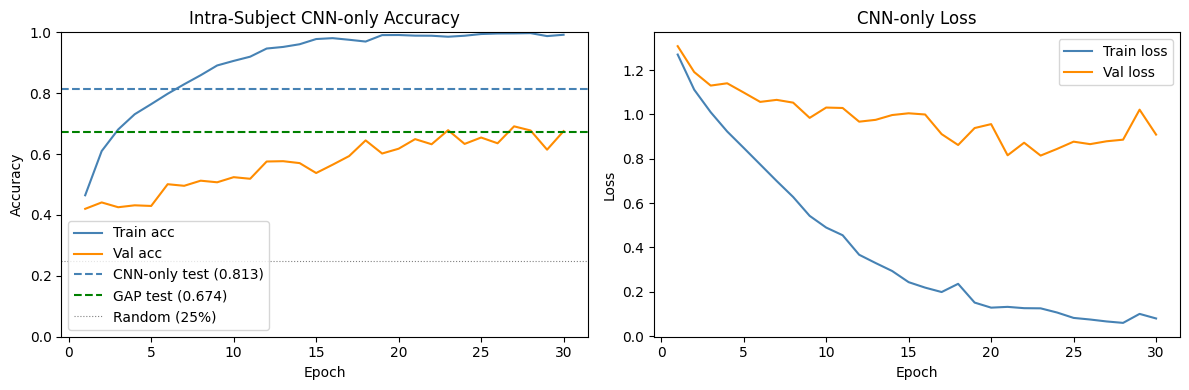

Saved cnn_only_intra_model.pt


In [53]:
import matplotlib.pyplot as plt

CNN_EPOCHS   = 30
CNN_LR       = 5e-4
CNN_PATIENCE = 5

criterion     = nn.CrossEntropyLoss()
cnn_model     = CNNOnly(n_channels=248, n_classes=4, window=WINDOW, dropout=0.3).to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LR, weight_decay=1e-4)

cnn_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc, patience_counter, best_state = 0, 0, None

for epoch in range(CNN_EPOCHS):
    tr_loss, tr_acc = run_epoch(train_loader, cnn_model, criterion, cnn_optimizer, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   cnn_model, criterion, train=False)
    cnn_history['train_loss'].append(tr_loss)
    cnn_history['train_acc'].append(tr_acc)
    cnn_history['val_loss'].append(vl_loss)
    cnn_history['val_acc'].append(vl_acc)
    print(f"Epoch {epoch+1:02d}/{CNN_EPOCHS} | tr {tr_loss:.4f}/{tr_acc:.3f} | val {vl_loss:.4f}/{vl_acc:.3f}")
    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        best_state       = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CNN_PATIENCE:
            print(f"Early stop at epoch {epoch+1}")
            break

cnn_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
_, cnn_te_acc = run_epoch(test_loader, cnn_model, criterion, train=False)

gap_intra = EEGConformerGAP(n_channels=248, n_classes=4, window=WINDOW,
                             num_layers=2, dropout=0.3).to(device)
gap_intra.load_state_dict(torch.load('final_best_gap_model.pt', map_location=device))
_, gap_te_acc = run_epoch(test_loader, gap_intra, criterion, train=False)

print(f"\nCNN-only test acc:        {cnn_te_acc:.3f}")
print(f"EEGConformerGAP test acc: {gap_te_acc:.3f}")
print(f"Delta (GAP - CNN):        {gap_te_acc - cnn_te_acc:+.3f}")

epochs_range = range(1, len(cnn_history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, cnn_history['train_acc'], color='steelblue',  label='Train acc')
ax1.plot(epochs_range, cnn_history['val_acc'],   color='darkorange', label='Val acc')
ax1.axhline(cnn_te_acc, color='steelblue',  linestyle='--', linewidth=1.5,
            label=f'CNN-only test ({cnn_te_acc:.3f})')
ax1.axhline(gap_te_acc, color='green',      linestyle='--', linewidth=1.5,
            label=f'GAP test ({gap_te_acc:.3f})')
ax1.axhline(0.25, color='grey', linestyle=':', linewidth=0.8, label='Random (25%)')
ax1.set_title('Intra-Subject CNN-only Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.set_ylim(0, 1)

ax2.plot(epochs_range, cnn_history['train_loss'], color='steelblue',  label='Train loss')
ax2.plot(epochs_range, cnn_history['val_loss'],   color='darkorange', label='Val loss')
ax2.set_title('CNN-only Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

torch.save(cnn_model.state_dict(), 'cnn_only_intra_model.pt')
print("Saved cnn_only_intra_model.pt")

### Cross-Subject: CNN-Only

In [54]:
# cross_cnn_model     = CNNOnly(n_channels=248, n_classes=4, window=WINDOW, dropout=0.3).to(device)
# cross_cnn_optimizer = torch.optim.Adam(cross_cnn_model.parameters(), lr=5e-4, weight_decay=1e-4)
# cross_cnn_criterion = nn.CrossEntropyLoss()

# cross_cnn_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
# best_val_acc, patience_counter, best_state = 0, 0, None

# for epoch in range(CNN_EPOCHS):
#     tr_loss, tr_acc = run_epoch(cross_train_loader, cross_cnn_model, cross_cnn_criterion,
#                                 cross_cnn_optimizer, train=True)
#     vl_loss, vl_acc = run_epoch(cross_val_loader, cross_cnn_model, cross_cnn_criterion, train=False)
#     cross_cnn_history['train_loss'].append(tr_loss)
#     cross_cnn_history['train_acc'].append(tr_acc)
#     cross_cnn_history['val_loss'].append(vl_loss)
#     cross_cnn_history['val_acc'].append(vl_acc)
#     print(f"Epoch {epoch+1:02d}/{CNN_EPOCHS} | tr {tr_loss:.4f}/{tr_acc:.3f} | val {vl_loss:.4f}/{vl_acc:.3f}")
#     if vl_acc > best_val_acc:
#         best_val_acc     = vl_acc
#         best_state       = {k: v.cpu().clone() for k, v in cross_cnn_model.state_dict().items()}
#         patience_counter = 0
#     else:
#         patience_counter += 1
#         if patience_counter >= CNN_PATIENCE:
#             print(f"Early stop at epoch {epoch+1}")
#             break

# cross_cnn_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# cnn_c1   = eval_acc(cross_cnn_model, cross_test1_loader)
# cnn_c2   = eval_acc(cross_cnn_model, cross_test2_loader)
# cnn_c3   = eval_acc(cross_cnn_model, cross_test3_loader)
# cnn_mean = (cnn_c1 + cnn_c2 + cnn_c3) / 3

# gap_cross = EEGConformerGAP(n_channels=248, n_classes=4, window=WINDOW,
#                              num_layers=2, dropout=0.3).to(device)
# gap_cross.load_state_dict(torch.load('final_cross_subject_model.pt', map_location=device))
# gap_c1   = eval_acc(gap_cross, cross_test1_loader)
# gap_c2   = eval_acc(gap_cross, cross_test2_loader)
# gap_c3   = eval_acc(gap_cross, cross_test3_loader)
# gap_mean = (gap_c1 + gap_c2 + gap_c3) / 3

# print(f"\nCNN-only — S1: {cnn_c1:.3f} | S2: {cnn_c2:.3f} | S3: {cnn_c3:.3f} | Mean: {cnn_mean:.3f}")
# print(f"GAP      — S1: {gap_c1:.3f} | S2: {gap_c2:.3f} | S3: {gap_c3:.3f} | Mean: {gap_mean:.3f}")
# print(f"Delta (GAP - CNN): {gap_mean - cnn_mean:+.3f}")

# subjects = ['Subject 1', 'Subject 2', 'Subject 3']
# x = np.arange(len(subjects))
# w = 0.35
# er = range(1, len(cross_cnn_history['train_loss']) + 1)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ax1.bar(x - w/2, [cnn_c1, cnn_c2, cnn_c3], w, label='CNN-only',        color='steelblue')
# ax1.bar(x + w/2, [gap_c1, gap_c2, gap_c3], w, label='EEGConformerGAP', color='darkorange')
# ax1.axhline(0.25, color='grey', linestyle=':', linewidth=0.8, label='Random (25%)')
# ax1.set_xticks(x); ax1.set_xticklabels(subjects)
# ax1.set_ylabel('Accuracy'); ax1.set_ylim(0, 1)
# ax1.set_title('Cross-Subject: CNN-only vs EEGConformerGAP'); ax1.legend()

# ax2.plot(er, cross_cnn_history['train_acc'], color='steelblue',  label='Train acc')
# ax2.plot(er, cross_cnn_history['val_acc'],   color='darkorange', label='Val acc')
# ax2.axhline(0.25, color='grey', linestyle=':', linewidth=0.8, label='Random (25%)')
# ax2.set_title('CNN-only Cross-Subject Training')
# ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
# ax2.legend(); ax2.set_ylim(0, 1)

# plt.tight_layout()
# plt.show()

# torch.save(cross_cnn_model.state_dict(), 'cnn_only_cross_model.pt')
# print("Saved cnn_only_cross_model.pt")

<!-- # References

https://github.com/OHBA-analysis/osl-foundation -->